In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from tensorflow import keras

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.target.value_counts()

1    165
0    138
Name: target, dtype: int64

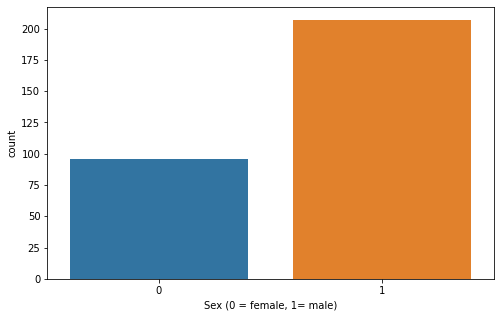

In [5]:
plt.figure(figsize = (8,5))
sns.countplot(x='sex', data=df)
plt.xlabel("Sex (0 = female, 1= male)")
plt.show()

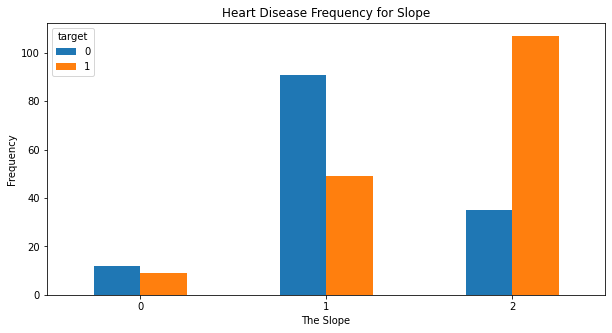

In [6]:
pd.crosstab(df.slope,df.target).plot(kind="bar",figsize=(10,5))
plt.title('Heart Disease Frequency for Slope')
plt.xlabel('The Slope')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

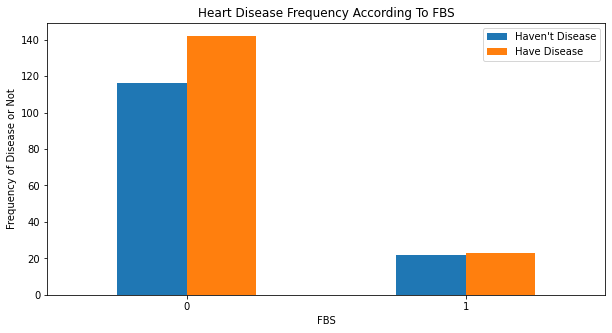

In [7]:
pd.crosstab(df.fbs,df.target).plot(kind="bar",figsize=(10,5))
plt.title('Heart Disease Frequency According To FBS')
plt.xlabel('FBS')
plt.xticks(rotation = 0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency of Disease or Not')
plt.show()

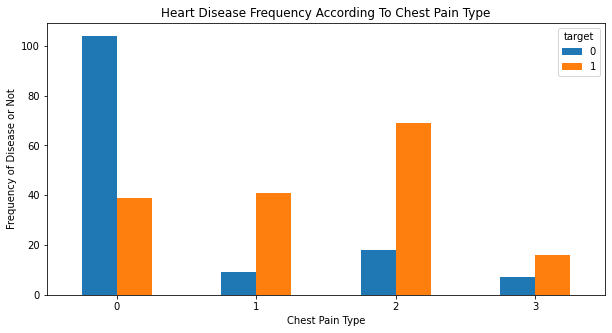

In [8]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,5))
plt.title('Heart Disease Frequency According To Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

In [9]:
cp = pd.get_dummies(df['cp'], prefix = "cp")
thal = pd.get_dummies(df['thal'], prefix = "thal")
slope = pd.get_dummies(df['slope'], prefix = "slope")

In [10]:
df = pd.concat([df, cp, thal, slope], axis = 1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0,0,1,0,0,0,1,0,1,0,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0,1,0,0,0,0,1,0,0,0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0,1,0,0,0,0,1,0,0,0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,1,0,0,0,0,0,1,0,0,0,1


In [11]:
df = df.drop(columns = ['cp', 'thal', 'slope'])
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,63,1,145,233,1,0,150,0,2.3,0,1,0,0,0,1,0,1,0,0,1,0,0
1,37,1,130,250,0,1,187,0,3.5,0,1,0,0,1,0,0,0,1,0,1,0,0
2,41,0,130,204,0,0,172,0,1.4,0,1,0,1,0,0,0,0,1,0,0,0,1
3,56,1,120,236,0,1,178,0,0.8,0,1,0,1,0,0,0,0,1,0,0,0,1
4,57,0,120,354,0,1,163,1,0.6,0,1,1,0,0,0,0,0,1,0,0,0,1


In [12]:
y = df["target"].values
X = df.drop(columns=["target"]).values

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [14]:
lr = LogisticRegression()

In [15]:
lr.fit(X_train,y_train)

lr.score(X_train,y_train),lr.score(X_test,y_test)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


(0.8636363636363636, 0.8524590163934426)

In [16]:
accuracies = {}

# Hyperparameter tunning

In [17]:
grid = {"C": np.logspace(-3,3,7), 
        "penalty": ["l1","l2"],
        "class_weight": ["balanced",None]}

lr = LogisticRegression(max_iter = 10000, solver = "saga")
lr_cv = GridSearchCV(lr, grid, cv=4)
lr_cv.fit(X_train,y_train)

GridSearchCV(cv=4, error_score=nan,
             estimator=LogisticRegression(C=1.0, class_weight=None, dual=False,
                                          fit_intercept=True,
                                          intercept_scaling=1, l1_ratio=None,
                                          max_iter=10000, multi_class='auto',
                                          n_jobs=None, penalty='l2',
                                          random_state=None, solver='saga',
                                          tol=0.0001, verbose=0,
                                          warm_start=False),
             iid='deprecated', n_jobs=None,
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'class_weight': ['balanced', None],
                         'penalty': ['l1', 'l2']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [18]:
print("Tuned hpyerparameters : ",lr_cv.best_params_)
print("Accuracy :",lr_cv.best_score_)

Tuned hpyerparameters :  {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
Accuracy : 0.8267076502732241


In [19]:
lr_best = lr_cv.best_estimator_

In [20]:
lr_best.score(X_train,y_train)

0.8471074380165289

In [21]:
lr_best.score(X_test,y_test)

0.819672131147541

In [22]:
accuracies["Logistic Regression"] = lr_best.score(X_test,y_test)*100

# Data normalization

In [23]:
scl = StandardScaler()
X_train_scl = scl.fit_transform(X_train)
X_test_scl = scl.transform(X_test)

In [24]:
grid = {"C": np.logspace(-3,3,7), 
        "penalty": ["l1","l2"],
        "class_weight": ["balanced",None]}

lr_2 = LogisticRegression(max_iter = 10000, solver = "saga")
lr_cv2 = GridSearchCV(lr_2, grid, cv=5)
lr_cv2.fit(X_train_scl,y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=LogisticRegression(C=1.0, class_weight=None, dual=False,
                                          fit_intercept=True,
                                          intercept_scaling=1, l1_ratio=None,
                                          max_iter=10000, multi_class='auto',
                                          n_jobs=None, penalty='l2',
                                          random_state=None, solver='saga',
                                          tol=0.0001, verbose=0,
                                          warm_start=False),
             iid='deprecated', n_jobs=None,
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'class_weight': ['balanced', None],
                         'penalty': ['l1', 'l2']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [25]:
print("Tuned hpyerparameters : ",lr_cv2.best_params_)
print("Accuracy :",lr_cv2.best_score_)

Tuned hpyerparameters :  {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2'}
Accuracy : 0.8348639455782314


In [26]:
lr_best2 = lr_cv2.best_estimator_

In [27]:
lr_best2.score(X_train_scl,y_train)

0.8553719008264463

In [28]:
lr_best2.score(X_test_scl,y_test)

0.9016393442622951

In [29]:
accuracies["Logistic Regression Scaled"] = lr_best2.score(X_test_scl,y_test)*100

# Neural Network

In [30]:
mlp = MLPClassifier(hidden_layer_sizes=(20,20), activation='relu', solver='adam', max_iter=10000,random_state=7)
mlp.fit(X_train,y_train)

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(20, 20), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=10000,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=7, shuffle=True, solver='adam',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)

In [31]:
mlp.score(X_train,y_train)

0.8677685950413223

In [32]:
mlp.score(X_test,y_test)

0.8524590163934426

In [34]:
mlp = MLPClassifier(max_iter=10000, random_state = 7)

grid = {
    'hidden_layer_sizes': [(20,20),(15,15),(15,),(20,)],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001,0.001, 0.01 ,0.05],
    'learning_rate': ['constant','adaptive'],
}

In [35]:
clf = GridSearchCV(mlp, grid, n_jobs=-1, cv=5)
clf.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=MLPClassifier(activation='relu', alpha=0.0001,
                                     batch_size='auto', beta_1=0.9,
                                     beta_2=0.999, early_stopping=False,
                                     epsilon=1e-08, hidden_layer_sizes=(100,),
                                     learning_rate='constant',
                                     learning_rate_init=0.001, max_fun=15000,
                                     max_iter=10000, momentum=0.9,
                                     n_iter_no_change=10,
                                     nesterovs_momentum=True, power_t=0.5,
                                     random_sta...
                                     solver='adam', tol=0.0001,
                                     validation_fraction=0.1, verbose=False,
                                     warm_start=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'alpha': [0.0001, 

In [36]:
mlp_best = clf.best_estimator_

In [37]:
mlp_best

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(15, 15), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=10000,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=7, shuffle=True, solver='adam',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)

In [38]:
mlp_best.score(X_train,y_train)

0.8181818181818182

In [39]:
mlp_best.score(X_test,y_test)

0.819672131147541

In [40]:
accuracies["NN"] = mlp_best.score(X_test,y_test)*100

# With scaled data

In [41]:
mlp2 = MLPClassifier(max_iter=10000, random_state = 7)

grid = {
    'hidden_layer_sizes': [(20,20),(15,15),(15,),(20,)],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001,0.001, 0.01 ,0.05],
    'learning_rate': ['constant','adaptive'],
}

In [42]:
clf2 = GridSearchCV(mlp2, grid, n_jobs=-1, cv=5)
clf2.fit(X_train_scl, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=MLPClassifier(activation='relu', alpha=0.0001,
                                     batch_size='auto', beta_1=0.9,
                                     beta_2=0.999, early_stopping=False,
                                     epsilon=1e-08, hidden_layer_sizes=(100,),
                                     learning_rate='constant',
                                     learning_rate_init=0.001, max_fun=15000,
                                     max_iter=10000, momentum=0.9,
                                     n_iter_no_change=10,
                                     nesterovs_momentum=True, power_t=0.5,
                                     random_sta...
                                     solver='adam', tol=0.0001,
                                     validation_fraction=0.1, verbose=False,
                                     warm_start=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'alpha': [0.0001, 

In [43]:
mlp_best2 = clf2.best_estimator_

In [44]:
mlp_best2

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(20,), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=10000,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=7, shuffle=True, solver='sgd',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)

In [45]:
mlp_best2.score(X_train_scl,y_train)

0.8636363636363636

In [46]:
mlp_best2.score(X_test_scl,y_test)

0.8688524590163934

In [47]:
accuracies["NN scaled"] = mlp_best2.score(X_test_scl,y_test)*100

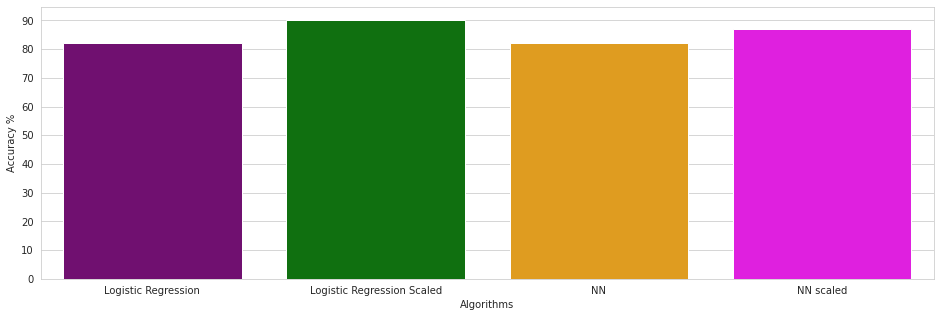

In [48]:
colors = ["purple", "green", "orange", "magenta"]

sns.set_style("whitegrid")
plt.figure(figsize=(16,5))
plt.yticks(np.arange(0,100,10))
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors)
plt.show()